In [1]:
import os
import load_dotenv
from load_dotenv import load_dotenv

# This function will load all the variable from the .env file and 
# make them available in the os.environ dictionary (env variables)
load_dotenv()

if os.environ.get("CLAUDE_API_KEY"):
    print("CLAUDE API KEY has been loaded")
else:
    raise ValueError("CLAUDE API KEY not found")

if os.environ.get("TAVILY_API_KEY"):
    print("TAVILY API KEY has been loaded")
else:
    raise ValueError("TAVILY API KEY not found")

CLAUDE API KEY has been loaded
TAVILY API KEY has been loaded


In [2]:
from langchain_anthropic import ChatAnthropic

llm_anthropic = ChatAnthropic(
    model = os.environ.get("CLAUDE_MODEL"),
    api_key = os.environ.get('CLAUDE_API_KEY'),
    temperature = 0,
    base_url = os.environ.get("CLAUDE_BASE_URL")
)
llm_anthropic

ChatAnthropic(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15', 'langchain-anthropic': '1.5.5'}}, model='vertex_ai.anthropic.claude-opus-4-6', max_tokens=4096, temperature=0.0, anthropic_api_url='https://genai-sharedservice-americas.pwcinternal.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

#### Pydantic LLM Schema

In [4]:
from pydantic import BaseModel, Field
from typing import List, TypedDict

class llm_schema(BaseModel):
    tasks: List[str] = Field(..., description="A list of tasks to be executed by the worker.")

llm_with_schema = llm_anthropic.with_structured_output(llm_schema)
# llm_with_schema.invoke("What is the capital of France and what is the population of France ?")

#### Graph Schema

In [5]:
class graph_schema(TypedDict):

    tasks: List[str]
    query: str
    results: List[str]
    summary: str

#### Creating Orchestrator Node

In [6]:
from langchain_core.prompts import ChatPromptTemplate

def orchestrator_node(state: graph_schema) -> graph_schema:

    # Fetching the user query from the state
    user_query = state['query']

    # Create the prompt for the LLM
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are an orchestrator that breaks down a user query into tasks for the worker."),
            ("user", f"User query: {user_query}. Please generate one prompt per task for the worker to complete. Return the tasks in a list format."),
        ]
    )

    # Create the chain
    chain = prompt | llm_with_schema

    # Run the chain with the user query as input
    response = chain.invoke({"query": user_query})

    # Update the state with the generated tasks
    state['tasks'] = response.tasks

    return state


#### Creating Worker Node

In [7]:
# Execute Function

def execute(query: str):

    response = llm_anthropic.invoke("Please execute this task {query}")
    return response.content

In [8]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state: graph_schema) -> graph_schema:

    tasks = state['tasks']
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:

        results_futures = executor.map(execute, tasks)
        for result in results_futures:
            results.append(result)

    state['results'] = results

    return state

#### Collector Node

In [9]:
def collector_node(state: graph_schema) -> graph_schema:

    results = state['results']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results from the worker."),
            ("user", f"Here are the results from the worker: {results}. Please summarize these results in a concise manner."),
        ]
    )

    chain = prompt | llm_anthropic

    summary = chain.invoke({"results": results})

    state['summary'] = summary.content

    return state

#### Creating Graph and Executing

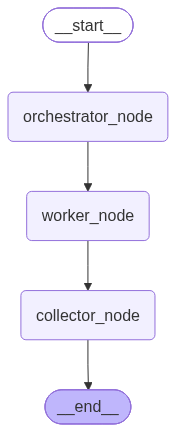

In [10]:
from langgraph.graph import StateGraph, START, END 
from IPython.display import Image, display

graph = StateGraph(graph_schema)

# Adding nodes to the Graph
graph.add_node("orchestrator_node", orchestrator_node)
graph.add_node("worker_node", worker_node)
graph.add_node("collector_node", collector_node)

# Adding edges to the Graph
graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()

Image(complex_graph.get_graph().draw_mermaid_png())

In [ ]:
complex_graph.invoke(
    {
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": ""
    }
)

In [ ]:
for chunk in complex_graph.stream(
    {
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": ""
    },
    stream_mode = "updates"
):
    print(chunk)